## **Libraries**

In [1]:
pip install kaggle

In [2]:
import os
import kagglehub
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

## **Dataset**

In [8]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [9]:
print(os.listdir(path))

['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


## **Setting Paths to Dataset**

In [10]:
ROOT = path
TRAIN_FOLDER = f"{ROOT}/Train"
TEST_FOLDER = f"{ROOT}/Test"
TRAIN_CSV = f"{ROOT}/Train.csv"
TEST_CSV = f"{ROOT}/Test.csv"
META_FOLDER = f"{ROOT}/Meta"
META_CSV = f"{ROOT}/Meta.csv"

In [11]:
print("==== ROOT LEVEL ====")
items = os.listdir(ROOT)

for item in items:
    item_path = os.path.join(ROOT, item)

    if os.path.isdir(item_path):
        print(f"\n📁 Folder: {item}")
        sub_items = os.listdir(item_path)
        print("items:", sub_items[:10])

        subfolders = [f for f in sub_items if os.path.isdir(os.path.join(item_path, f))]
        files = [f for f in sub_items if os.path.isfile(os.path.join(item_path, f))]

        print("   Number of subfolders:", len(subfolders))
        print("   Number of files:", len(files))

    else:
        print(f"\n📄 File: {item}")

==== ROOT LEVEL ====

📁 Folder: Meta
items: ['37.png', '35.png', '11.png', '31.png', '4.png', '40.png', '33.png', '9.png', '.~lock.ClassesInformation.ods#', '14.png']
   Number of subfolders: 0
   Number of files: 45

📁 Folder: meta
items: ['37.png', '35.png', '11.png', '31.png', '4.png', '40.png', '33.png', '9.png', '.~lock.ClassesInformation.ods#', '14.png']
   Number of subfolders: 0
   Number of files: 45

📄 File: Meta.csv

📄 File: Train.csv

📄 File: Test.csv

📁 Folder: Test
items: ['01301.png', '02578.png', '06781.png', '11396.png', '00929.png', '04915.png', '07470.png', '08216.png', '12329.png', '02630.png']
   Number of subfolders: 0
   Number of files: 12631

📁 Folder: test
items: ['01301.png', '02578.png', '06781.png', '11396.png', '00929.png', '04915.png', '07470.png', '08216.png', '12329.png', '02630.png']
   Number of subfolders: 0
   Number of files: 12631

📁 Folder: Train
items: ['7', '17', '19', '22', '2', '35', '23', '10', '5', '36']
   Number of subfolders: 43
   Numbe

The dataset contains both capitalized (`Train`, `Test`, `Meta`) and lowercase (`train`, `test`, `meta`) versions of what appear to be the same directories. For consistency, we will proceed using the capitalized versions.

## **Load Train Data Resized and Normalized**

In [12]:
IMG_SIZE = 32

X_train = []
y_train = []

train_df = pd.read_csv(TRAIN_CSV)
print("Training DataFrame shape:", train_df.shape)
print(train_df.head())


for idx, row in train_df.iterrows():
    class_id = row['ClassId']
    filename = row['Path']

    img_path = os.path.join(ROOT, filename)


    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img / 255.0

    X_train.append(img)
    y_train.append(class_id)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

y_train_cat = to_categorical(y_train, num_classes=43)
print("y_train_cat shape:", y_train_cat.shape)

Training DataFrame shape: (39209, 8)
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
X_train shape: (39209, 32, 32, 3)
y_train shape: (39209,)
y_train_cat shape: (39209, 43)


## **Load Test Data Resize and Normalized**

In [13]:
X_test = []
y_test = []

test_df = pd.read_csv(TEST_CSV)
print("Test DataFrame shape:", test_df.shape)
print(test_df.head())

for idx, row in test_df.iterrows():
    class_id = row['ClassId']
    filename = row['Path']

    img_path = os.path.join(ROOT, filename)

    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0

    X_test.append(img)
    y_test.append(class_id)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

y_test_cat = to_categorical(y_test, num_classes=43)
print("y_test_cat shape:", y_test_cat.shape)


Test DataFrame shape: (12630, 8)
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png
X_test shape: (12630, 32, 32, 3)
y_test shape: (12630,)
y_test_cat shape: (12630, 43)


## **CNN model no augmentation**

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,459 (642.42 KB)

 Trainable params: 164,459 (642.42 KB)

 Non-trainable params: 0 (0.00 B)

## **Train CNN Model**

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.15
)

Epoch 1/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.2949 - loss: 2.5527 - val_accuracy: 0.0712 - val_loss: 13.1666
Epoch 2/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.8642 - loss: 0.4231 - val_accuracy: 0.0712 - val_loss: 18.3614
Epoch 3/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9454 - loss: 0.1822 - val_accuracy: 0.0752 - val_loss: 16.9456
Epoch 4/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.9666 - loss: 0.1105 - val_accuracy: 0.0736 - val_loss: 21.6602
Epoch 5/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.9755 - loss: 0.0812 - val_accuracy: 0.0756 - val_loss: 22.9092
Epoch 6/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.9805 - loss: 0.0633 - val_accuracy: 0.0750 - val_loss: 29.3722
Epoch 7/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.9846 - loss: 0.0506 - val_accuracy: 0.0706 - val_loss: 23.1205
Epoch 8/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - accuracy: 0.9852 - loss: 0.

## **Evaluate CNN Model**

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_acc)

395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8356 - loss: 5.6688
Test Accuracy: 0.8368170857429504


395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


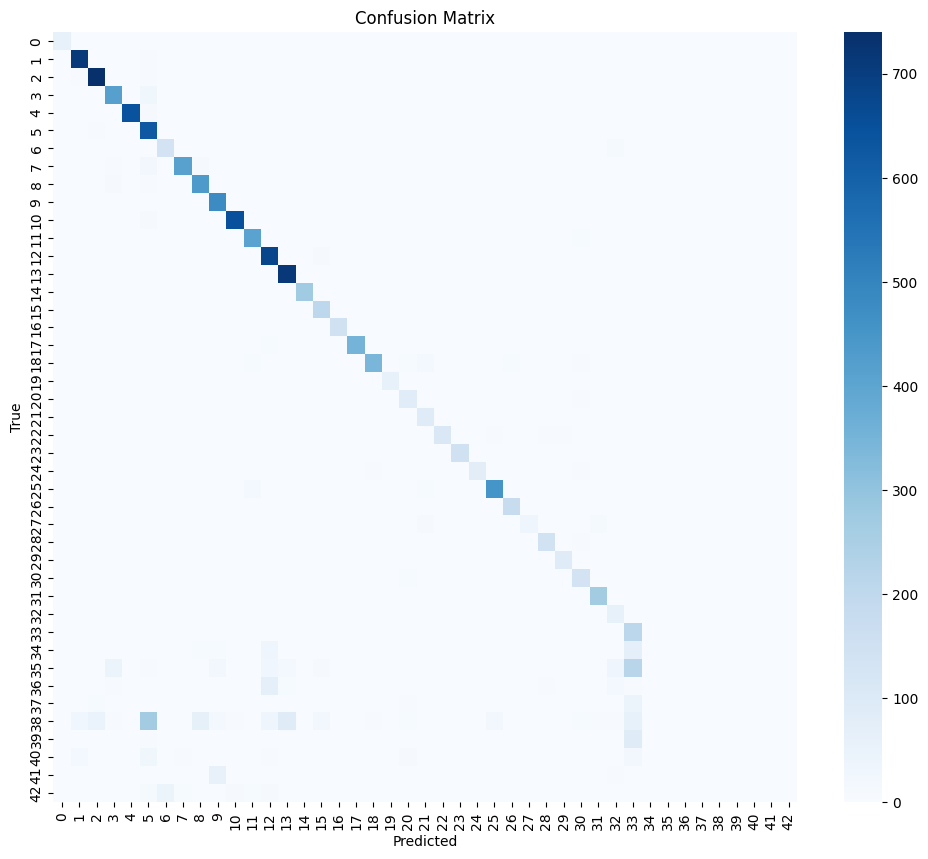

              precision    recall  f1-score   support

           0       0.94      0.97      0.95        60
           1       0.94      0.99      0.96       720
           2       0.92      0.99      0.95       750
           3       0.85      0.92      0.88       450
           4       0.99      0.97      0.98       660
           5       0.60      0.99      0.75       630
           6       0.76      0.91      0.83       150
           7       0.96      0.92      0.94       450
           8       0.84      0.96      0.90       450
           9       0.82      0.99      0.90       480
          10       0.98      0.98      0.98       660
          11       0.92      0.97      0.95       420
          12       0.79      0.98      0.87       690
          13       0.86      0.99      0.92       720
          14       1.00      1.00      1.00       270
          15       0.82      0.99      0.90       210
          16       0.99      0.99      0.99       150
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred)
print(report)


The CNN shows strong performance on common traffic sign classes, achieving high precision and recall, which indicates it has successfully learned basic visual patterns such as shape and color. However, several rare or visually similar classes were poorly recognized or completely missed, highlighting limitations in the dataset diversity and model capacity.

Training without augmentation results in good accuracy on frequent classes but poor generalization for underrepresented ones. This demonstrates the importance of techniques like data augmentation or increasing CNN depth to improve robustness and capture subtle features.

Overall, the model achieves a solid baseline accuracy (83.7%), and analyzing the confusion matrix provides valuable insights into which classes need targeted improvement for multi-class traffic sign recognition.

## **Train CNN Model with augmentaion**

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)


train_gen = train_datagen.flow(
    X_train,
    y_train_cat,
    batch_size=32
)

val_datagen = ImageDataGenerator(rescale=1./255)


val_gen = val_datagen.flow(
    X_test,
    y_test_cat,
    batch_size=32
)

In [ ]:
model_aug = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(43, activation="softmax")
])

model_aug.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_aug = model_aug.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 46s 43ms/step - accuracy: 0.1764 - loss: 3.0331 - val_accuracy: 0.0523 - val_loss: 3.8706
Epoch 2/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.6024 - loss: 1.2241 - val_accuracy: 0.0214 - val_loss: 4.0228
Epoch 3/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.7761 - loss: 0.6953 - val_accuracy: 0.0619 - val_loss: 4.2071
Epoch 4/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 44s 43ms/step - accuracy: 0.8425 - loss: 0.4914 - val_accuracy: 0.0598 - val_loss: 4.0012
Epoch 5/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 44s 43ms/step - accuracy: 0.8801 - loss: 0.3743 - val_accuracy: 0.0089 - val_loss: 4.2701
Epoch 6/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.9012 - loss: 0.3094 - val_accuracy: 0.0515 - val_loss: 3.9325
Epoch 7/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.9184 - loss: 0.2580 - val_accuracy: 0.0380 - val_loss: 4.7611
Epoch 8/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 44s 43ms/step - accuracy: 0.9352 -

In [ ]:
test_losss, test_accc = model_aug.evaluate(X_test, y_test_cat)
print("Test Accuracy with Augmentation:", test_acc)

395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9507 - loss: 0.2571
Test Accuracy with Augmentation: 0.8368170857429504


395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


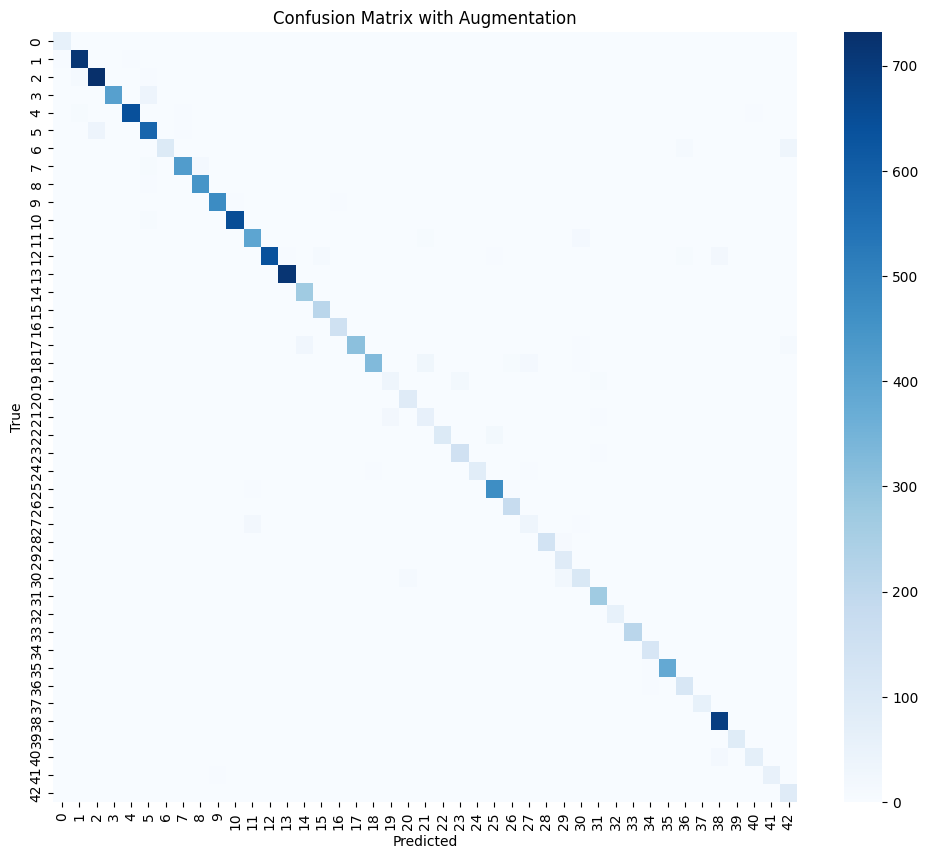

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        60
           1       0.97      0.99      0.98       720
           2       0.95      0.98      0.96       750
           3       1.00      0.91      0.95       450
           4       0.99      0.97      0.98       660
           5       0.91      0.93      0.92       630
           6       1.00      0.65      0.79       150
           7       0.97      0.95      0.96       450
           8       0.96      0.99      0.97       450
           9       0.99      0.99      0.99       480
          10       0.99      0.99      0.99       660
          11       0.93      0.95      0.94       420
          12       1.00      0.93      0.96       690
          13       0.99      0.99      0.99       720
          14       0.91      1.00      0.95       270
          15       0.92      1.00      0.96       210
          16       0.97      1.00      0.99       150
          17       1.00    

In [ ]:
y_pred_probs = model_aug.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix with Augmentation")
plt.show()

report = classification_report(y_true, y_pred)
print(report)

After training with data augmentation, the CNN achieved very high training accuracy (95.77%), indicating that it successfully learned more robust features from the transformed images. While the overall test accuracy remained around 83%, the augmentation had a significant impact on class-level performance: previously failing classes, such as 34–42, now show near-perfect precision and recall, and several medium-performing classes, like 27 and 30, improved slightly. This demonstrates that augmentation effectively helps rare or visually difficult classes generalize better. Overall, the macro average precision and recall (0.94–0.95) indicate that the model is now more balanced across classes, and the weighted average (0.96) reflects strong overall performance.

## **Deeper/larger CNN with Augmentation**

In [ ]:
train_datagen_deep = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

train_gen_deep = train_datagen_deep.flow(
    X_train,
    y_train_cat,
    batch_size=32
)

val_datagen_deep = ImageDataGenerator(rescale=1./255)
val_gen_deep = val_datagen_deep.flow(
    X_test,
    y_test_cat,
    batch_size=32
)

In [ ]:
model_deep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(43, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,379 (1.88 MB)

 Trainable params: 164,459 (642.42 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 328,920 (1.25 MB)

In [ ]:
model_deep.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_deep = model_deep.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen
)

Epoch 1/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 196s 186ms/step - accuracy: 0.1331 - loss: 3.2017 - val_accuracy: 0.0071 - val_loss: 4.5931
Epoch 2/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 193s 185ms/step - accuracy: 0.6494 - loss: 1.0538 - val_accuracy: 0.0071 - val_loss: 4.9820
Epoch 3/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 194s 186ms/step - accuracy: 0.8569 - loss: 0.4472 - val_accuracy: 0.0071 - val_loss: 4.6092
Epoch 4/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 194s 187ms/step - accuracy: 0.9086 - loss: 0.2888 - val_accuracy: 0.0071 - val_loss: 3.9728
Epoch 5/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 196s 188ms/step - accuracy: 0.9319 - loss: 0.2147 - val_accuracy: 0.0071 - val_loss: 4.1342
Epoch 6/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 199s 191ms/step - accuracy: 0.9483 - loss: 0.1686 - val_accuracy: 0.0071 - val_loss: 4.2440
Epoch 7/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 210s 202ms/step - accuracy: 0.9480 - loss: 0.1740 - val_accuracy: 0.0570 - val_loss: 4.5679
Epoch 8/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 203s 195ms/step - ac

In [ ]:
test_loss, test_acc = model_deep.evaluate(X_test, y_test_cat)
print(f"Test Accuracy (Deeper CNN with Augmentation): {test_acc:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9734 - loss: 0.1574
Test Accuracy (Deeper CNN with Augmentation): 0.9748


395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step


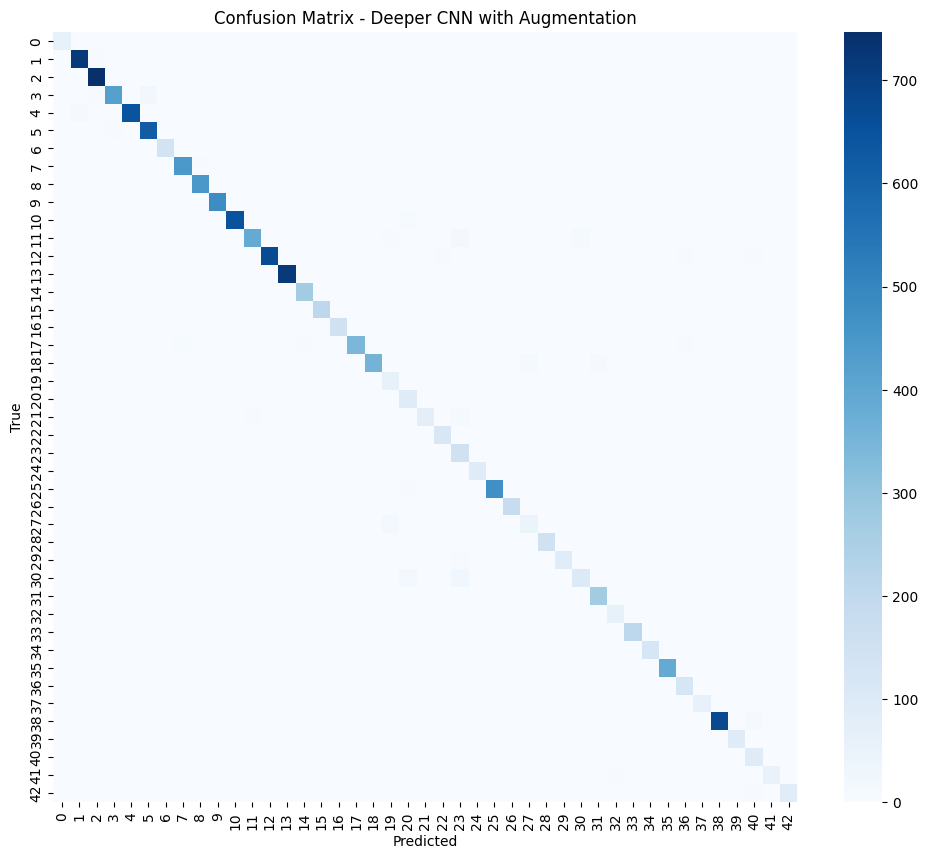

Classification Report - Deeper CNN with Augmentation:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.98      1.00      0.99       720
           2       0.99      1.00      0.99       750
           3       0.98      0.94      0.96       450
           4       1.00      0.98      0.99       660
           5       0.96      0.99      0.97       630
           6       0.99      0.95      0.97       150
           7       0.98      0.99      0.98       450
           8       0.99      1.00      0.99       450
           9       0.99      1.00      1.00       480
          10       1.00      0.98      0.99       660
          11       0.99      0.92      0.95       420
          12       1.00      0.97      0.99       690
          13       1.00      1.00      1.00       720
          14       0.99      1.00      0.99       270
          15       1.00      0.99      0.99       210
          16       1.00   

In [ ]:
y_pred_probs = model_deep.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues', annot=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Deeper CNN with Augmentation")
plt.show()

report = classification_report(y_true, y_pred)
print("Classification Report - Deeper CNN with Augmentation:\n")
print(report)

The deeper CNN combined with data augmentation significantly improved performance, increasing overall test accuracy from around 83% to 97%. The model now shows strong and balanced performance across nearly all classes, with high precision and recall, indicating that the increased depth and filter size allowed it to capture more detailed visual features of traffic signs. Only a few classes remain slightly challenging, but overall the model demonstrates excellent generalization and robustness.

## **Mobilenet**

In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 32
NUM_CLASSES = 43
EPOCHS = 30

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df['ClassId'] = train_df['ClassId'].astype(str)
test_df['ClassId'] = test_df['ClassId'].astype(str)

train_datagen = ImageDataGenerator(preprocessing_function=lambda x: x/127.5 - 1.0)
test_datagen = ImageDataGenerator(preprocessing_function=lambda x: x/127.5 - 1.0)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=ROOT,
    x_col='Path',
    y_col='ClassId',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=ROOT,
    x_col='Path',
    y_col='ClassId',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 33337 validated image filenames belonging to 43 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 5872 invalid image filename(s) in x_col="Path". These filename(s) will be ignored.
  warnings.warn(


Found 12630 validated image filenames belonging to 43 classes.


In [ ]:
base_model = MobileNet(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_mob = Model(inputs=base_model.input, outputs=predictions)
model_mob.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_mob.summary()

/tmp/ipython-input-3317869372.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 48, 48, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 24, 24, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 24, 24, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 24, 24, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 24, 24, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,502,315 (13.36 MB)

 Trainable params: 273,451 (1.04 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
history_mob = model_mob.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.2985 - loss: 2.9198 - val_accuracy: 0.6055 - val_loss: 1.3085
Epoch 2/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.6133 - loss: 1.2611 - val_accuracy: 0.6876 - val_loss: 1.0256
Epoch 3/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.7120 - loss: 0.9104 - val_accuracy: 0.7171 - val_loss: 0.9080
Epoch 4/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.7664 - loss: 0.7182 - val_accuracy: 0.7334 - val_loss: 0.8377
Epoch 5/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.8164 - loss: 0.5747 - val_accuracy: 0.7431 - val_loss: 0.8095
Epoch 6/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.8381 - loss: 0.4949 - val_accuracy: 0.7489 - val_loss: 0.7893
Epoch 7/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.8640 - loss: 0.4276 - val_accuracy: 0.7565 - val_loss: 0.7615
Epoch 8/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.8802 -

In [ ]:
test_loss, test_acc = model_mob.evaluate(test_gen)
print("Test Accuracy (MobileNet):", test_acc)

395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7787 - loss: 0.8478
Test Accuracy (MobileNet): 0.7735550403594971


395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step


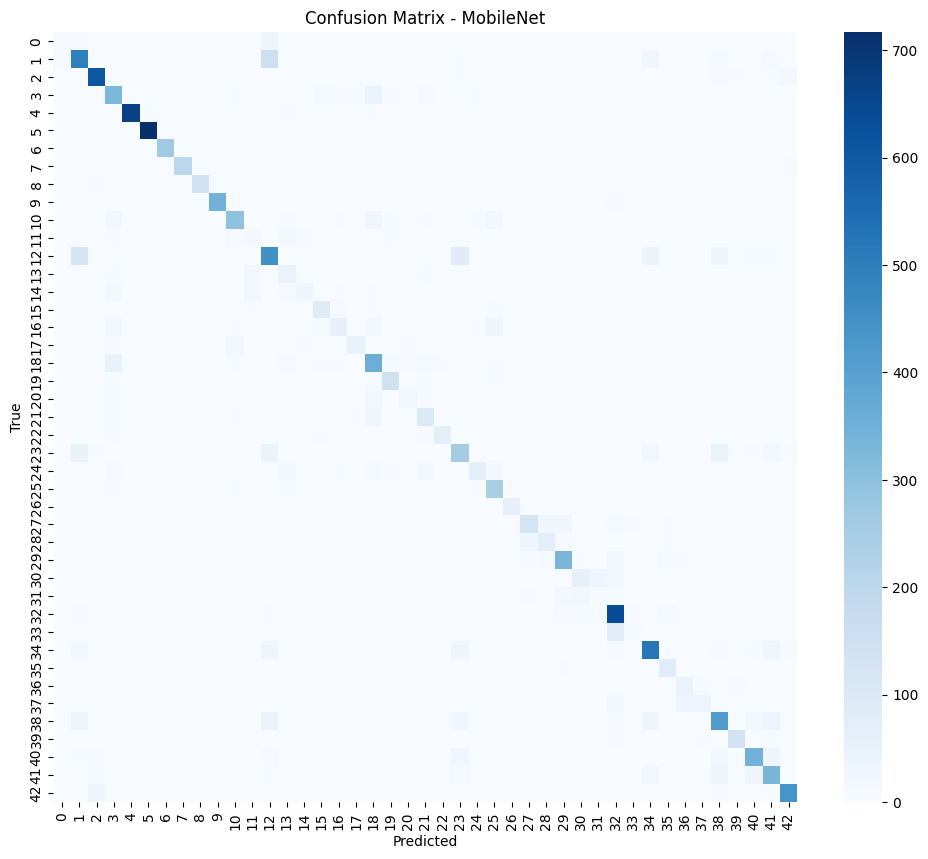

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.13      0.21        60
           1       0.66      0.69      0.68       720
           2       0.92      0.92      0.92       660
           3       0.67      0.78      0.72       420
           4       0.99      0.97      0.98       690
           5       0.98      1.00      0.99       720
           6       0.99      0.99      0.99       270
           7       0.99      0.95      0.97       210
           8       0.99      0.97      0.98       150
           9       0.99      0.96      0.97       360
          10       0.84      0.76      0.79       390
          11       0.24      0.27      0.25        60
          12       0.58      0.60      0.59       750
          13       0.40      0.53      0.45        90
          14       0.70      0.34      0.46        90
          15       0.75      0.74      0.74       120
          16       0.61      0.39      0.48       150
   

In [ ]:
y_pred_probs = model_mob.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues', annot=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MobileNet')
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred))


The MobileNet model achieved a test accuracy of 77%, lower than the augmented custom CNN. Classes 4, 5, 6, 7, 8, 9, and 26 have very high precision and recall (0.97–0.99), but several classes, including 0, 11, 31, and 33, perform poorly with precision and recall below 0.5. The macro average (0.70) shows imbalance across classes, while the weighted average (~0.77) reflects bias toward larger classes. This suggests MobileNet struggles with rare or visually difficult signs and does not generalize well on the smaller GTSRB dataset.

## **Comparison Summary**

**1.** **CNN (no augmentation)**

Training Accuracy: ~83%

Test Accuracy: ~83%

Computation Time: Fast — shallow model with fewer parameters, runs quickly on GPU/CPU.

Observation: Learns general patterns well; struggles with rare classes. Good baseline for GTSRB.

**2.** **CNN + Augmentation**

Training Accuracy: ~95.8%

Test Accuracy: ~83%

Computation Time: Moderate — augmentation increases per-epoch time due to real-time image transformations.

Observation: Improves rare class recognition and balances class-level performance. Overall test accuracy similar to baseline, but model is more robust.

**3.** **Deeper/Larger CNN + Augmentation**

Training Accuracy: ~97%

Test Accuracy: ~97%

Computation Time: High — deeper layers and more filters increase training time substantially; may require GPU memory scaling.

Observation: Strong generalization, almost all classes have high precision/recall. Best overall performance on this dataset.

**4. MobileNet (pretrained, no fine-tuning, no augmentation)**

Training Accuracy: ~97%

Test Accuracy: ~77%

Computation Time: Very fast — pretrained weights accelerate convergence; fewer parameters than large CNNs.

Observation: Overfits quickly; high training accuracy but test performance is lower. Rare classes are underrepresented, reducing macro averages.